## Bibliotecas

In [ ]:
# Remove versões antigas ou conflitantes das bibliotecas do ecossistema PyTorch Geometric.
#
# O comando:
# - "-y" confirma automaticamente a remoção;
# - "> /dev/null 2>&1" oculta mensagens do terminal.
#
# Essas bibliotecas são responsáveis por:
# - operações em grafos;
# - convoluções em grafos;
# - manipulação temporal de grafos;
# - otimizações específicas do PyTorch Geometric.
!pip uninstall -y torch-scatter torch-sparse torch-cluster \
    torch-spline-conv torch-geometric pyg-lib \
    torch-geometric-temporal > /dev/null 2>&1


# Importa a biblioteca PyTorch.
#
# O PyTorch é utilizado para:
# - construção de redes neurais;
# - cálculo automático de gradientes;
# - computação em GPU.
import torch

# Importa a biblioteca sys.
#
# Essa biblioteca fornece acesso a funcionalidades
# relacionadas ao interpretador Python e ao sistema.
import sys


# Obtém a versão instalada do PyTorch.
#
# Exemplo:
# "2.2.1+cu121" -> "2.2.1"
#
# split('+')[0] remove a parte relacionada ao CUDA.
torch_version = torch.__version__.split('+')[0]

# Obtém a versão do CUDA utilizada pelo PyTorch.
#
# CUDA é a tecnologia da NVIDIA usada para acelerar
# computações em GPU.
cuda_version = torch.version.cuda


# Exibe a versão instalada do PyTorch.
print(f"PyTorch: {torch.__version__}")

# Exibe a versão do CUDA detectada.
print(f"CUDA: {cuda_version}")


# Verifica se CUDA está disponível.
#
# Caso não exista suporte à GPU,
# será utilizada a versão CPU das bibliotecas.
if cuda_version is None:

    # Define a tag para instalação CPU.
    device_tag = "cpu"

else:

    # Remove o ponto da versão CUDA.
    #
    # Exemplo:
    # "12.1" -> "cu121"
    device_tag = f"cu{cuda_version.replace('.', '')}"


# Obtém apenas a versão principal e secundária do PyTorch.
#
# Exemplo:
# "2.2.1" -> "2.2"
major_minor = ".".join(torch_version.split('.')[:2])

# Monta a tag usada pelos wheels do PyTorch Geometric.
#
# Exemplo:
# "2.2" -> "2.2.0"
torch_tag = f"{major_minor}.0"


# Cria a URL dos wheels compatíveis com:
# - versão do PyTorch;
# - versão CUDA/CPU.
#
# Wheels são pacotes binários pré-compilados.
url = f"https://data.pyg.org/whl/torch-{torch_tag}+{device_tag}.html"


# Exibe a URL utilizada para instalação.
print(f"Using wheels from: {url}")


# Instala as dependências principais do PyTorch Geometric.
#
# Bibliotecas instaladas:
#
# pyg-lib:
# - operações otimizadas para grafos.
#
# torch-scatter:
# - operações eficientes de agregação.
#
# torch-sparse:
# - suporte para matrizes esparsas.
#
# torch-cluster:
# - algoritmos de agrupamento e vizinhança.
#
# torch-spline-conv:
# - convoluções spline em grafos.
#
# "-f {url}" indica onde localizar os wheels corretos.
!pip install -q pyg-lib torch-scatter torch-sparse \
    torch-cluster torch-spline-conv \
    -f {url}


# Instala a biblioteca principal PyTorch Geometric.
#
# Essa biblioteca fornece:
# - datasets de grafos;
# - camadas GNN;
# - utilitários para grafos;
# - modelos prontos.
!pip install -q torch-geometric


# Instala o módulo temporal do PyTorch Geometric.
#
# Essa extensão é usada para:
# - grafos dinâmicos;
# - séries temporais em grafos;
# - redes neurais espaço-temporais.
!pip install -q torch-geometric-temporal


# Importa a biblioteca principal PyTorch Geometric.
import torch_geometric

# Importa o módulo temporal do PyTorch Geometric.
import torch_geometric_temporal

# Importa a biblioteca pyg-lib.
#
# Essa biblioteca contém operações otimizadas
# utilizadas internamente pelo PyTorch Geometric.
import pyg_lib


# Exibe a versão instalada do PyTorch Geometric.
print("PyG version:", torch_geometric.__version__)

# Exibe a versão instalada do módulo temporal.
print("Temporal version:", torch_geometric_temporal.__version__)

# Confirma que o pyg-lib foi instalado corretamente.
print("pyg-lib OK")


# Importa o NeighborLoader.
#
# NeighborLoader é utilizado para:
# - amostragem de vizinhos;
# - treinamento em grafos grandes;
# - mini-batches de subgrafos.
from torch_geometric.loader import NeighborLoader


# Importa a função temporal_signal_split.
#
# Essa função divide séries temporais em:
# - treino;
# - validação;
# - teste.
from torch_geometric_temporal.signal import temporal_signal_split


# Importa o dataset WikiMathsDatasetLoader.
#
# Esse dataset contém informações temporais
# relacionadas à Wikipedia Mathematics.
#
# É utilizado em problemas de previsão temporal em grafos.
from torch_geometric_temporal.dataset import WikiMathsDatasetLoader


# Importa a arquitetura EvolveGCNH.
#
# EvolveGCNH é uma Graph Neural Network temporal,
# projetada para aprender padrões em grafos dinâmicos.
#
# Ela combina:
# - convoluções em grafos;
# - aprendizado temporal;
# - atualização dinâmica dos pesos.
from torch_geometric_temporal.nn.recurrent import EvolveGCNH


# Confirma que os módulos temporais foram carregados corretamente.
print("Temporal imports OK")

PyTorch: 2.10.0+cpu
CUDA: None
Using wheels from: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.4/682.4 kB 29.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 828.2/828.2 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.9/306.9 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 5.7 MB/s eta 0:00:00
PyG version: 2.7.0
Temporal version: 0.54.0
pyg-lib OK
Temporal imports OK


In [ ]:
# Importa a biblioteca PyTorch.
#
# O PyTorch é uma das principais bibliotecas
# para Deep Learning e aprendizado de máquina.
#
# Ele oferece:
# - criação de redes neurais;
# - cálculo automático de gradientes;
# - suporte para GPU;
# - manipulação eficiente de tensores.
import torch


# Importa a biblioteca Pandas.
#
# O Pandas é utilizado para:
# - manipulação de tabelas;
# - leitura de arquivos CSV/Excel;
# - análise e processamento de dados.
#
# Sua principal estrutura é o DataFrame.
import pandas as pd


# Importa a biblioteca Matplotlib.
#
# pyplot fornece funções para:
# - criação de gráficos;
# - visualizações;
# - análise visual de métricas e resultados.
#
# Muito utilizada em Machine Learning e Ciência de Dados.
import matplotlib.pyplot as plt


# Importa a biblioteca tqdm.
#
# tqdm cria barras de progresso visuais
# para loops e processos iterativos.
#
# Isso facilita o acompanhamento do treinamento
# e processamento de dados longos.
from tqdm import tqdm


# Importa o módulo PyTorch Geometric Temporal.
#
# Essa biblioteca é uma extensão do PyTorch Geometric
# especializada em:
# - grafos temporais;
# - séries temporais em grafos;
# - redes neurais espaço-temporais.
import torch_geometric_temporal


# Exibe a versão instalada da biblioteca.
#
# Isso ajuda a verificar compatibilidade
# e evitar problemas entre versões.
print(torch_geometric_temporal.__version__)


# Importa a função temporal_signal_split.
#
# Essa função é usada para dividir datasets temporais
# em subconjuntos de:
# - treino;
# - validação;
# - teste.
#
# Muito útil em problemas de previsão temporal.
from torch_geometric_temporal.signal import temporal_signal_split


# Importa o dataset WikiMathsDatasetLoader.
#
# Esse loader fornece um dataset temporal baseado
# em informações matemáticas da Wikipédia.
#
# O dataset pode ser utilizado para:
# - previsão temporal;
# - aprendizado em grafos dinâmicos;
# - análise de séries temporais em redes.
from torch_geometric_temporal.dataset import WikiMathsDatasetLoader


# Importa a arquitetura EvolveGCNH.
#
# EvolveGCNH é uma Graph Neural Network temporal,
# desenvolvida para trabalhar com grafos dinâmicos.
#
# Essa arquitetura:
# - combina convoluções em grafos;
# - modela dependências temporais;
# - atualiza dinamicamente os pesos da GCN.
#
# O "H" no nome refere-se ao uso de GRU/LSTM
# para evolução temporal dos parâmetros.
from torch_geometric_temporal.nn.recurrent import EvolveGCNH

0.54.0


# Temporal Graph Neural Networks

Até agora vimos apenas arestas e features que não mudam. Contudo, em vários problemas podemos analisar de forma temporal a evolução do grafo. Como por exemplo redes sociais: Podemos ver o crescimento da rede de um usuário ao longo do tempo.

Então existem duas categorias diferentes de T-GNN:

- 1° Grafos estáticos com sinais temporais: Nesse caso o grafo não muda, mas as features e os labels sim.
- 2° Grafos dinâmico com sinais temporais: A topologia do grafo, features e os nós mudam ao longo do tempo.

## Grafos estáticos com sinais temporais

Para isso vamos usar a arquitetura EvolveGNN: Combina GNN com RNN. Existem duas variates principais:

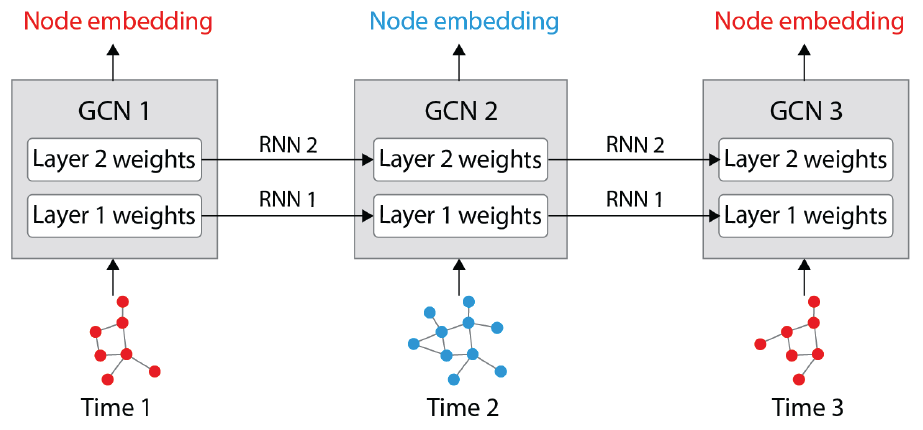
- EvolveGCN-H: Rene Neural Recorrente (RNN) considera tanto os parâmetros da GCN anterior quanto o embedding do nó atual.
- EvolveGCN-O: Só utiliza os parâmetros anteriores da GCN

Normalmente EvolveGCN-H usa Gated Recurrent Unit (GRU) e EvolveGCN-O usa LSTM.

EvolveGCN-H:

$$
    W_t^{(l)} = GRU(H_t^{(l)}, W_{t-1}^{(l)})
$$

$$
    H_t^{l+1} = GCN(A_t, H_t^{(l)}, W_t^{(t)}) = D^{-1/2}A^TD^{-1/2}H_t^{(l)}W_t^{{(t)}^T}
$$

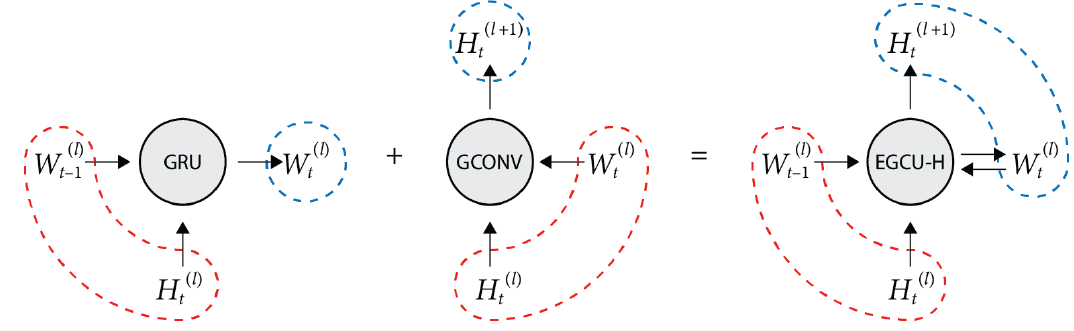

EvolveGCN - O:

$$
    W_t^{(l)} = LSTM(W_{t-1}^{(l)})
$$

$$
    H_t^{(l+1)} = GCN(A_t, H_t^{(l)}, W_t^{(t)}) = D^{-1/2}A^TD^{-1/2}H_t^{(l)}W_t^{{(l)}^T}
$$

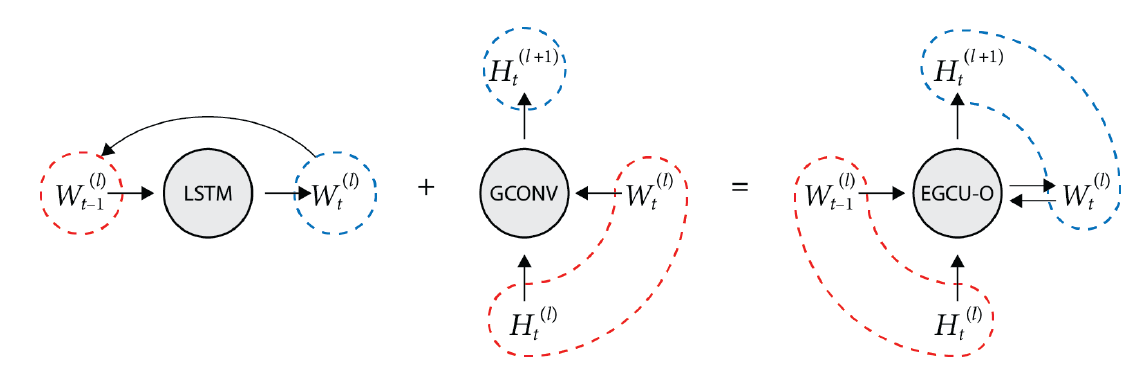

Para escolher um dos dois grafos uma forma de decidir é:

- EvolveGCN-H: Funciona melhor quando as features são mais essenciais, porque RNN explicitamente incorpora os embeddings dos nós
- EvolveGCN-O: Olha mais nas mudanças das topologias

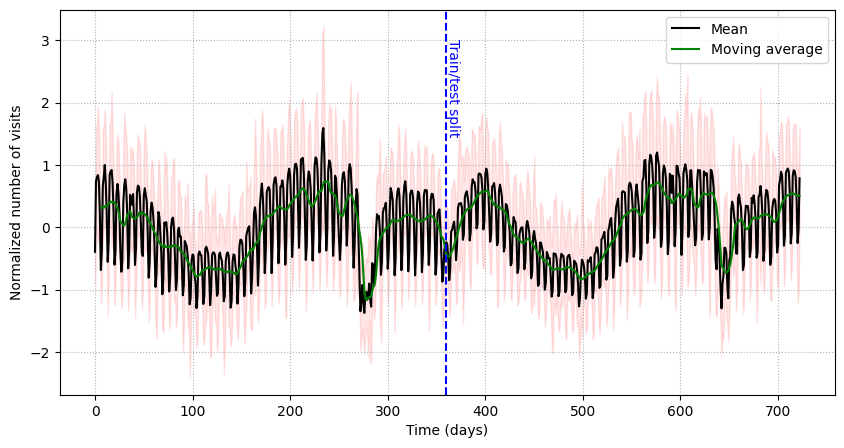

In [ ]:
# Carrega o dataset WikiMaths.
#
# Esse dataset contém informações temporais sobre
# acessos a páginas relacionadas à matemática na Wikipédia.
#
# Cada snapshot do dataset representa:
# - um grafo em determinado instante de tempo;
# - conexões entre páginas;
# - quantidade de acessos/visitas.
#
# O método get_dataset() retorna toda a sequência temporal.
dataset = WikiMathsDatasetLoader().get_dataset()


# Divide o dataset em:
# - conjunto de treino;
# - conjunto de teste.
#
# train_ratio=0.5 indica que:
# - 50% dos snapshots serão usados para treino;
# - 50% serão usados para teste.
#
# Como se trata de um dataset temporal,
# a divisão respeita a ordem cronológica dos dados.
train_dataset, test_dataset = temporal_signal_split(
    dataset,
    train_ratio=0.5
)


# Calcula a média de acessos para cada snapshot temporal.
#
# snapshot.y contém os valores alvo (targets)
# associados aos nós do grafo.
#
# mean() calcula a média das visitas.
#
# item() converte o tensor PyTorch em valor numérico Python.
mean_cases = [
    snapshot.y.mean().item()
    for snapshot in dataset
]


# Calcula o desvio padrão das visitas
# para cada instante temporal.
#
# O desvio padrão mede a dispersão dos dados:
# - valores altos -> maior variabilidade;
# - valores baixos -> dados mais homogêneos.
std_cases = [
    snapshot.y.std().item()
    for snapshot in dataset
]


# Cria um DataFrame Pandas contendo a média dos acessos.
#
# Cada linha representa um instante temporal.
df = pd.DataFrame(
    mean_cases,
    columns=['mean']
)


# Adiciona uma coluna com os desvios padrão.
df['std'] = pd.DataFrame(
    std_cases,
    columns=['std']
)


# Calcula a média móvel de 7 dias.
#
# rolling(7) cria uma janela deslizante de tamanho 7.
#
# mean() calcula a média dentro dessa janela.
#
# Isso suaviza oscilações temporais,
# facilitando a visualização de tendências.
df['rolling'] = df['mean'].rolling(7).mean()


# Cria uma figura para visualização dos dados.
#
# figsize=(10,5) define:
# - largura = 10;
# - altura = 5.
plt.figure(figsize=(10,5))


# Plota a média diária de acessos.
#
# 'k-' indica:
# - k = black (preto);
# - - = linha contínua.
plt.plot(
    df['mean'],
    'k-',
    label='Mean'
)


# Plota a média móvel de 7 dias.
#
# 'g-' indica:
# - g = green (verde);
# - - = linha contínua.
plt.plot(
    df['rolling'],
    'g-',
    label='Moving average'
)


# Adiciona uma grade ao gráfico.
#
# linestyle=':' cria linhas pontilhadas.
plt.grid(linestyle=':')


# Preenche a região entre:
# média - desvio padrão
# média + desvio padrão
#
# Isso representa visualmente a variabilidade dos dados.
#
# color='r' -> vermelho
# alpha=0.1 -> transparência
plt.fill_between(
    df.index,
    df['mean'] - df['std'],
    df['mean'] + df['std'],
    color='r',
    alpha=0.1
)


# Desenha uma linha vertical indicando
# o ponto de separação entre treino e teste.
#
# x=360 define a posição temporal da divisão.
plt.axvline(
    x=360,
    color='b',
    linestyle='--'
)


# Adiciona um texto indicando a divisão treino/teste.
#
# rotation=-90 rotaciona o texto verticalmente.
plt.text(
    360,
    1.5,
    'Train/test split',
    rotation=-90,
    color='b'
)


# Define o rótulo do eixo X.
#
# Representa o tempo em dias.
plt.xlabel('Time (days)')


# Define o rótulo do eixo Y.
#
# Representa o número normalizado de visitas.
plt.ylabel('Normalized number of visits')


# Exibe a legenda do gráfico.
#
# loc='upper right' posiciona a legenda
# no canto superior direito.
plt.legend(loc='upper right')

In [ ]:
# Importa a biblioteca PyTorch.
#
# O PyTorch é utilizado para:
# - construção de redes neurais;
# - manipulação de tensores;
# - treinamento de modelos Deep Learning.
import torch


# Define uma seed fixa para reprodutibilidade.
#
# Isso garante que:
# - inicializações aleatórias;
# - pesos;
# - resultados experimentais
#
# sejam reproduzíveis em diferentes execuções.
torch.manual_seed(0)


# Define a classe TemporalGNN.
#
# Essa classe implementa uma Graph Neural Network Temporal,
# utilizando a arquitetura EvolveGCNH.
#
# O modelo é capaz de:
# - aprender padrões espaciais no grafo;
# - capturar dependências temporais;
# - realizar previsão em séries temporais de grafos.
class TemporalGNN(torch.nn.Module):

    """
    Classe: TemporalGNN

    Objetivo:
    Implementar uma rede neural temporal para grafos,
    combinando:
    - convoluções em grafos;
    - aprendizado temporal;
    - previsão de valores futuros.

    A arquitetura utiliza:
    - EvolveGCNH;
    - camada linear final.
    """

    # Método construtor da classe.
    def __init__(self, node_count, dim_in):

        """
        Função: __init__

        Objetivo:
        Inicializar a arquitetura da rede temporal.

        Parâmetros:
        node_count -> Número de nós do grafo.
        dim_in     -> Número de características de entrada.
        """

        # Inicializa a classe pai.
        super().__init__()

        # Define a camada recorrente EvolveGCNH.
        #
        # Essa camada:
        # - aprende padrões temporais;
        # - atualiza dinamicamente os pesos;
        # - propaga informações no grafo.
        self.recurrent = EvolveGCNH(
            node_count,
            dim_in
        )

        # Define uma camada linear final.
        #
        # Essa camada transforma os embeddings aprendidos
        # em um único valor de saída por nó.
        self.linear = torch.nn.Linear(
            dim_in,
            1
        )


    # Define o fluxo de dados da rede.
    def forward(self, x, edge_index, edge_weight):

        """
        Função: forward

        Objetivo:
        Processar os dados temporais do grafo.

        Parâmetros:
        x           -> Características dos nós.
        edge_index  -> Estrutura de conexões do grafo.
        edge_weight -> Pesos das arestas.

        Retorno:
        Valores previstos para cada nó.
        """

        # Aplica a camada recorrente temporal.
        #
        # Aqui ocorre:
        # - propagação das informações no grafo;
        # - aprendizado temporal;
        # - atualização dinâmica dos embeddings.
        h = self.recurrent(
            x,
            edge_index,
            edge_weight
        )

        # Aplica a função de ativação ReLU.
        #
        # ReLU remove valores negativos
        # e adiciona não-linearidade ao modelo.
        h = torch.relu(h)

        # Aplica a camada linear final.
        #
        # Isso produz a previsão final para cada nó.
        h = self.linear(h)

        # Remove dimensões extras do tensor.
        #
        # squeeze(-1) remove a última dimensão,
        # deixando a saída em formato mais simples.
        return h.squeeze(-1)


# Define a função de perda.
#
# MSELoss = Mean Squared Error.
#
# Essa função mede o erro quadrático médio entre:
# - valores previstos;
# - valores reais.
#
# Muito utilizada em problemas de regressão.
criterion = torch.nn.MSELoss()


# Cria a instância do modelo TemporalGNN.
#
# dataset[0].x.shape[0] -> número de nós.
# dataset[0].x.shape[1] -> número de características.
model = TemporalGNN(
    dataset[0].x.shape[0],
    dataset[0].x.shape[1]
)


# Define o otimizador Adam.
#
# Adam ajusta automaticamente os pesos da rede
# utilizando os gradientes calculados.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


# Coloca o modelo em modo de treinamento.
model.train()


# Inicia o loop principal de treinamento.
#
# tqdm exibe uma barra de progresso visual.
for epoch in tqdm(range(50)):

    # Inicializa a perda total da época.
    total_loss = 0

    # Percorre todos os snapshots temporais do treino.
    for snapshot in train_dataset:

        # Zera os gradientes acumulados.
        optimizer.zero_grad()

        # Executa o forward pass.
        #
        # Conversões:
        # float() -> garante tipo float.
        # long()  -> garante índices inteiros.
        y_pred = model(
            snapshot.x.float(),
            snapshot.edge_index.long(),
            snapshot.edge_attr.float()
        )

        # Obtém os valores reais.
        y_true = snapshot.y.float()

        # Calcula a perda.
        loss = criterion(
            y_pred,
            y_true
        )

        # Executa o backpropagation.
        #
        # Calcula automaticamente os gradientes.
        loss.backward()

        # Atualiza os pesos da rede.
        optimizer.step()

        # Acumula a perda da época.
        total_loss += loss.item()

    # Exibe a perda total da época.
    print(
        f"Epoch {epoch+1} | Loss: {total_loss:.4f}"
    )


# -----------------------------
# Etapa de avaliação
# -----------------------------

# Coloca o modelo em modo de avaliação.
model.eval()

# Inicializa variável de perda.
loss = 0


# Desativa cálculo de gradientes.
#
# Isso reduz uso de memória e processamento.
with torch.no_grad():

    # Percorre os snapshots do conjunto de teste.
    for i, snapshot in enumerate(test_dataset):

        # Executa o forward pass.
        y_pred = model(
            snapshot.x.float(),
            snapshot.edge_index.long(),
            snapshot.edge_attr.float()
        )

        # Obtém os valores reais.
        y_true = snapshot.y.float()

        # Calcula o erro quadrático médio.
        mse = criterion(
            y_pred,
            y_true
        )

        # Acumula a perda total.
        loss += mse.item()


# Calcula a média final da perda.
loss = loss / (i + 1)


# Exibe o MSE final.
#
# Quanto menor o valor,
# melhor o desempenho do modelo.
print(f"MSE = {loss:.4f}")

  0%|          | 0/50 [00:00<?, ?it/s]


RuntimeError: Output 0 of UnbindBackward0 is a view and its base or another view of its base has been modified inplace. This view is the output of a function that returns multiple views. Such functions do not allow the output views to be modified inplace. You should replace the inplace operation by an out-of-place one.

In [ ]:
# Importa a camada GConvGRU da biblioteca PyTorch Geometric Temporal.
#
# GConvGRU combina:
# - Graph Convolutional Networks (GCN);
# - Gated Recurrent Units (GRU).
#
# Essa arquitetura é usada para:
# - grafos dinâmicos;
# - séries temporais em grafos;
# - previsão temporal em redes complexas.
#
# A camada consegue aprender:
# - relações espaciais entre os nós;
# - dependências temporais ao longo do tempo.
from torch_geometric_temporal.nn.recurrent import GConvGRU


# Importa o módulo functional do PyTorch.
#
# Esse módulo contém:
# - funções de ativação;
# - operações matemáticas;
# - utilidades para redes neurais.
import torch.nn.functional as F


# Define uma seed fixa para reprodutibilidade.
#
# Isso garante resultados consistentes
# entre diferentes execuções do código.
torch.manual_seed(0)


# Define a classe TemporalGNN.
#
# Essa classe implementa uma Graph Neural Network Temporal
# baseada em GConvGRU.
#
# O modelo combina:
# - convoluções em grafos;
# - aprendizado recorrente temporal;
# - previsão contínua/regressão.
class TemporalGNN(torch.nn.Module):

    """
    Classe: TemporalGNN

    Objetivo:
    Implementar uma rede neural temporal para grafos,
    utilizando:
    - GConvGRU;
    - camada linear final;
    - aprendizado espaço-temporal.

    A classe herda de torch.nn.Module,
    permitindo utilizar toda a infraestrutura do PyTorch.
    """

    # Método construtor da classe.
    def __init__(self, node_features):

        """
        Função: __init__

        Objetivo:
        Inicializar a arquitetura da rede.

        Parâmetros:
        node_features -> Número de características dos nós.
        """

        # Inicializa a classe pai.
        super().__init__()

        # Define a camada recorrente GConvGRU.
        #
        # Parâmetros:
        #
        # in_channels:
        # Número de características de entrada.
        #
        # out_channels:
        # Número de neurônios ocultos produzidos pela camada.
        #
        # K:
        # Ordem da convolução espectral.
        # Define quantos níveis de vizinhança serão considerados.
        self.recurrent = GConvGRU(
            in_channels=node_features,
            out_channels=32,
            K=2
        )

        # Define a camada linear final.
        #
        # Essa camada transforma os embeddings temporais
        # em um único valor de saída.
        self.linear = torch.nn.Linear(
            32,
            1
        )


    # Define o fluxo de dados da rede.
    def forward(self, x, edge_index, edge_weight):

        """
        Função: forward

        Objetivo:
        Processar os dados temporais do grafo.

        Parâmetros:
        x           -> Características dos nós.
        edge_index  -> Estrutura de conexões do grafo.
        edge_weight -> Pesos das arestas.

        Retorno:
        Valores previstos para cada nó.
        """

        # Aplica a camada GConvGRU.
        #
        # Aqui ocorre:
        # - propagação das informações no grafo;
        # - aprendizado temporal;
        # - atualização recorrente dos embeddings.
        h = self.recurrent(
            x,
            edge_index,
            edge_weight
        )

        # Aplica a função de ativação ReLU.
        #
        # ReLU remove valores negativos
        # e adiciona não-linearidade ao modelo.
        h = F.relu(h)

        # Aplica a camada linear final.
        #
        # Produz a previsão final para cada nó.
        h = self.linear(h)

        # Remove dimensões extras do tensor.
        #
        # squeeze() simplifica o formato da saída.
        return h.squeeze()


# Cria a instância do modelo.
#
# dataset[0].x.shape[1] representa:
# número de características por nó.
model = TemporalGNN(
    dataset[0].x.shape[1]
)


# Define o otimizador Adam.
#
# Adam ajusta automaticamente os pesos da rede
# utilizando os gradientes calculados.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)


# Define a função de perda.
#
# MSELoss calcula o erro quadrático médio.
#
# Muito utilizada em problemas de regressão.
criterion = torch.nn.MSELoss()


# Coloca o modelo em modo de treinamento.
model.train()


# Inicia o loop principal de treinamento.
#
# tqdm exibe uma barra de progresso visual.
for epoch in tqdm(range(50)):

    # Inicializa a perda total da época.
    total_loss = 0

    # Percorre todos os snapshots temporais do treino.
    for snapshot in train_dataset:

        # Zera os gradientes acumulados.
        optimizer.zero_grad()

        # Executa o forward pass.
        y_pred = model(
            snapshot.x.float(),
            snapshot.edge_index.long(),
            snapshot.edge_attr.float()
        )

        # Obtém os valores reais.
        y_true = snapshot.y.float()

        # Calcula a perda.
        loss = criterion(
            y_pred,
            y_true
        )

        # Executa o backpropagation.
        #
        # Calcula automaticamente os gradientes.
        loss.backward()

        # Atualiza os pesos da rede.
        optimizer.step()

        # Acumula a perda da época.
        total_loss += loss.item()

    # Exibe a perda total da época.
    print(
        f"Epoch {epoch+1} | Loss: {total_loss:.4f}"
    )


# -----------------------------
# Etapa de avaliação
# -----------------------------

# Coloca o modelo em modo de avaliação.
model.eval()

# Inicializa variável de perda.
loss = 0

# Lista que armazenará previsões médias.
y_preds = []


# Desativa o cálculo de gradientes.
#
# Isso reduz uso de memória e processamento.
with torch.no_grad():

    # Percorre os snapshots do conjunto de teste.
    for i, snapshot in enumerate(test_dataset):

        # Executa o forward pass.
        y_pred = model(
            snapshot.x.float(),
            snapshot.edge_index.long(),
            snapshot.edge_attr.float()
        )

        # Obtém os valores reais.
        y_true = snapshot.y.float()

        # Calcula o erro quadrático médio.
        mse = criterion(
            y_pred,
            y_true
        )

        # Acumula a perda total.
        loss += mse.item()

        # Armazena a média das previsões.
        #
        # Isso pode ser usado posteriormente
        # para visualização/análise temporal.
        y_preds.append(
            y_pred.mean().item()
        )


# Calcula o MSE médio final.
loss = loss / (i + 1)


# Exibe o erro final do modelo.
#
# Quanto menor o valor,
# melhor o desempenho da rede.
print(f"MSE = {loss:.4f}")

  2%|▏         | 1/50 [00:21<17:29, 21.42s/it]

Epoch 1 | Loss: 185.8395


  4%|▍         | 2/50 [00:41<16:33, 20.70s/it]

Epoch 2 | Loss: 167.4066


  6%|▌         | 3/50 [01:00<15:33, 19.87s/it]

...

 98%|█████████▊| 49/50 [16:12<00:19, 19.33s/it]

Epoch 49 | Loss: 155.1711


100%|██████████| 50/50 [16:31<00:00, 19.84s/it]

Epoch 50 | Loss: 155.1137


MSE = 0.5109


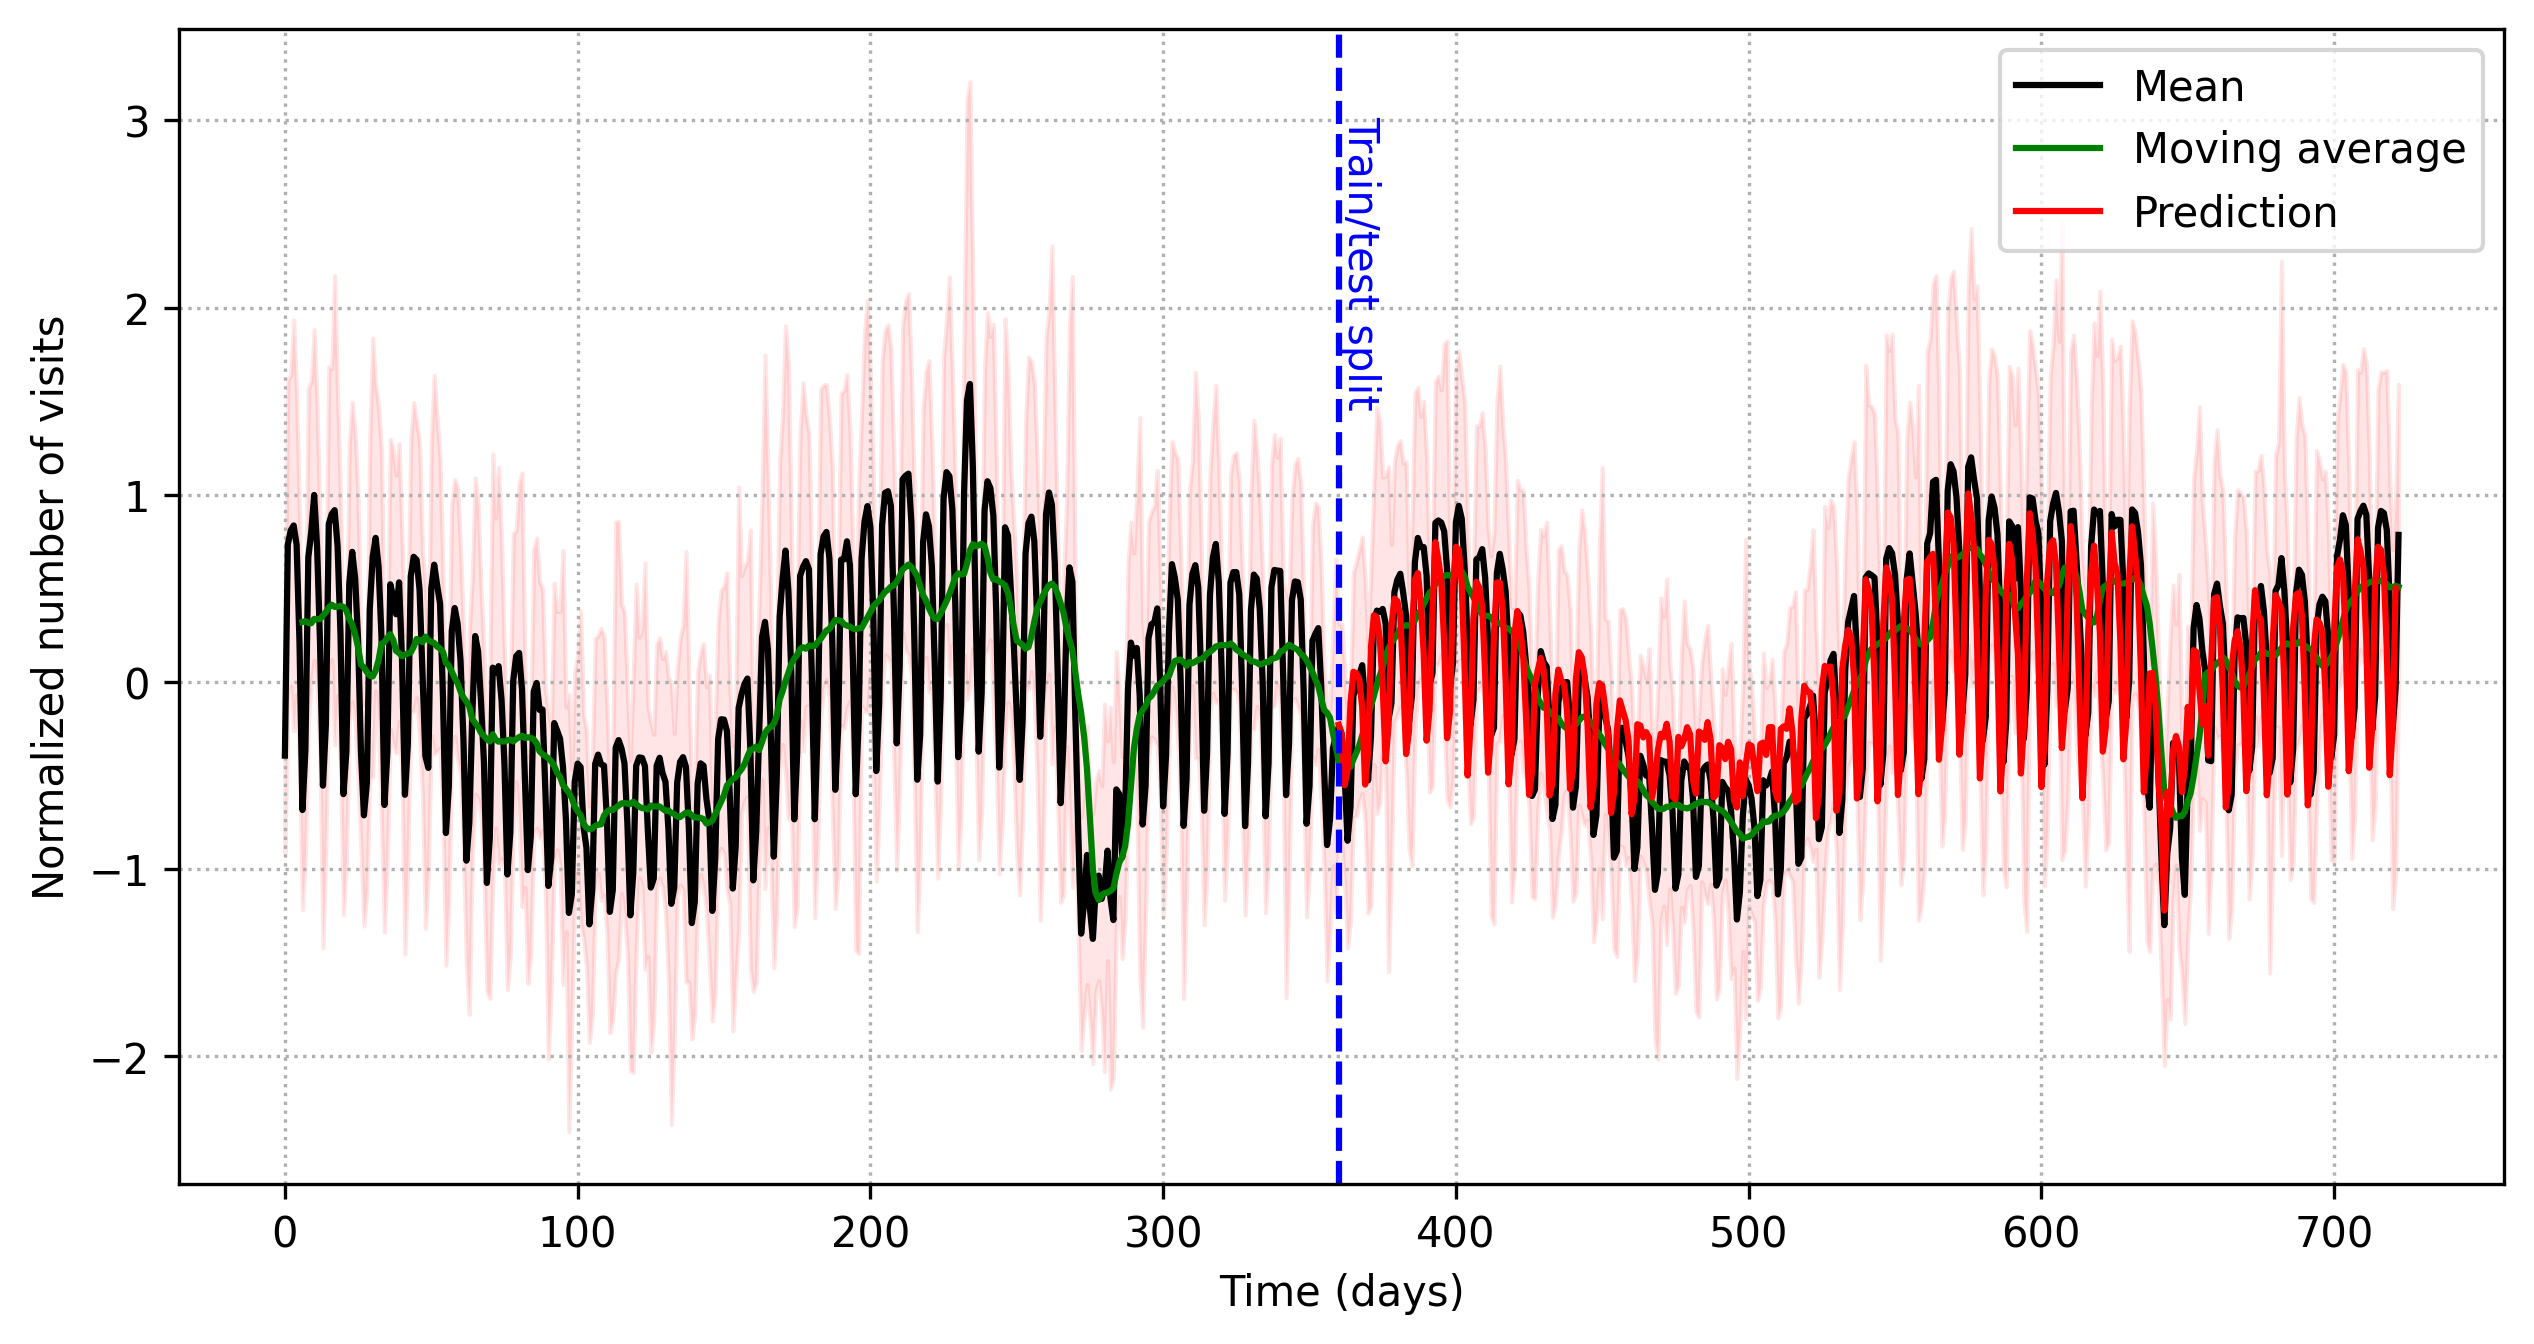

In [ ]:
# Plot do desempenho do modelo, onde as previsões do modelo para os snapshots de teste são calculadas e armazenadas na lista y_preds, 
# e em seguida, essas previsões são plotadas junto com a média real dos acessos (df['mean']) e a média móvel (df['rolling']), permitindo 
# uma comparação visual entre os valores reais e as previsões do modelo ao longo do tempo.
y_preds = [model(snapshot.x, snapshot.edge_index, snapshot.edge_attr).squeeze().detach().numpy().mean() for snapshot in test_dataset]

plt.figure(figsize=(10,5), dpi=300)
plt.plot(df['mean'], 'k-', label='Mean')
plt.plot(df['rolling'], 'g-', label='Moving average')
plt.plot(range(360,722), y_preds, 'r-', label='Prediction')
plt.grid(linestyle=':')
plt.fill_between(df.index, df['mean']-df['std'], df['mean']+df['std'], color='r', alpha=0.1)
plt.axvline(x=360, color='b', linestyle='--')
plt.text(360, 1.5, 'Train/test split', rotation=-90, color='b')
plt.xlabel('Time (days)')
plt.ylabel('Normalized number of visits')
plt.legend(loc='upper right')

In [ ]:
## Exemplo do Código do EvolveGCN-O
from torch_geometric_temporal.nn.recurrent import EvolveGCNO

# Define a classe TemporalGNN utilizando EvolveGCNO.
class TemporalGNN(torch.nn.Module):
    def __init__(self, dim_in):
        super().__init__()
        self.recurrent = EvolveGCNO(dim_in, 1)
        self.linear = torch.nn.Linear(dim_in, 1)

    def forward(self, x, edge_index, edge_weight):
        h = self.recurrent(x, edge_index, edge_weight).relu()
        h = self.linear(h)
        return h

model = TemporalGNN(dataset[0].x.shape[1])

## Grafos dinâmicos com sinais temporais

A arquitetura que vamos usar para esse caso é a MPNN-LSTM


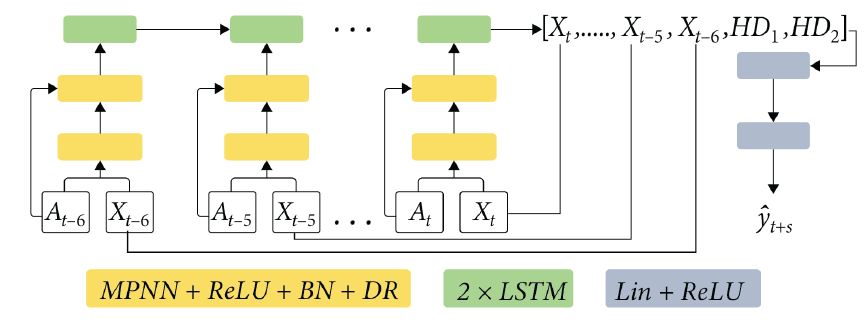

Text(0, 0.5, 'Mean normalized number of cases')

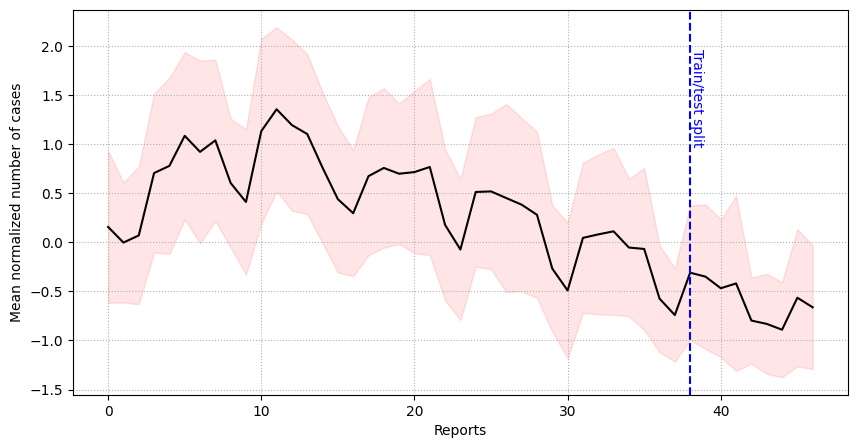

In [ ]:
## Resolvendo o dataset de Covid da Inglaterra
import pandas as pd
import matplotlib.pyplot as plt
from torch_geometric_temporal.dataset import EnglandCovidDatasetLoader # Dataset temporal de casos de Covid na Inglaterra
from torch_geometric_temporal.signal import temporal_signal_split # Função para dividir o dataset temporal em treino e teste

dataset = EnglandCovidDatasetLoader().get_dataset(lags=14)
train_dataset, test_dataset = temporal_signal_split(dataset, train_ratio=0.8)

mean_cases = [snapshot.y.mean().item() for snapshot in dataset]
std_cases = [snapshot.y.std().item() for snapshot in dataset]
df = pd.DataFrame(mean_cases, columns=['mean'])
df['std'] = pd.DataFrame(std_cases, columns=['std'])

plt.figure(figsize=(10,5))
plt.plot(df['mean'], 'k-')
plt.grid(linestyle=':')
plt.fill_between(df.index, df['mean']-df['std'], df['mean']+df['std'], color='r', alpha=0.1)
plt.axvline(x=38, color='b', linestyle='--', label='Train/test split')
plt.text(38, 1, 'Train/test split', rotation=-90, color='b')
plt.xlabel('Reports')
plt.ylabel('Mean normalized number of cases')

In [ ]:
# Importa a camada MPNNLSTM da biblioteca PyTorch Geometric Temporal.
#
# MPNNLSTM significa:
# Message Passing Neural Network + LSTM.
#
# Essa arquitetura combina:
# - propagação de mensagens em grafos;
# - aprendizado recorrente temporal;
# - modelagem espaço-temporal.
#
# O modelo é ideal para:
# - grafos dinâmicos;
# - séries temporais em redes;
# - previsão temporal em estruturas conectadas.
from torch_geometric_temporal.nn.recurrent import MPNNLSTM


# Define a classe TemporalGNN.
#
# Essa classe implementa uma Graph Neural Network Temporal
# utilizando a arquitetura MPNNLSTM.
#
# A rede combina:
# - aprendizado espacial no grafo;
# - memória temporal com LSTM;
# - previsão contínua/regressão.
class TemporalGNN(torch.nn.Module):

    """
    Classe: TemporalGNN

    Objetivo:
    Implementar uma rede neural temporal para grafos,
    utilizando:
    - Message Passing;
    - memória temporal LSTM;
    - regularização com Dropout;
    - camada linear final.

    A arquitetura é adequada para problemas
    de previsão em grafos dinâmicos.
    """

    # Método construtor da classe.
    def __init__(self, dim_in, dim_h, num_nodes):

        """
        Função: __init__

        Objetivo:
        Inicializar a arquitetura da rede.

        Parâmetros:
        dim_in   -> Número de características de entrada.
        dim_h    -> Número de neurônios ocultos.
        num_nodes -> Quantidade total de nós do grafo.
        """

        # Inicializa a classe pai.
        super().__init__()

        # Define a camada recorrente MPNNLSTM.
        #
        # Parâmetros:
        #
        # dim_in:
        # Número de características de entrada.
        #
        # dim_h:
        # Dimensão oculta dos embeddings.
        #
        # num_nodes:
        # Número total de nós do grafo.
        #
        # 1:
        # Número de camadas recorrentes.
        #
        # 0.5:
        # Taxa de dropout interno.
        self.recurrent = MPNNLSTM(
            dim_in,
            dim_h,
            num_nodes,
            1,
            0.5
        )

        # Define uma camada Dropout.
        #
        # Dropout:
        # - desativa neurônios aleatoriamente;
        # - reduz overfitting;
        # - melhora generalização.
        self.dropout = torch.nn.Dropout(0.5)

        # Define a camada linear final.
        #
        # Entrada:
        # 2*dim_h + dim_in
        #
        # Isso ocorre porque o MPNNLSTM concatena:
        # - embeddings ocultos;
        # - memória temporal;
        # - características originais.
        #
        # A saída possui 1 valor por nó.
        self.linear = torch.nn.Linear(
            2 * dim_h + dim_in,
            1
        )


    # Define o fluxo de dados da rede.
    def forward(self, x, edge_index, edge_weight):

        """
        Função: forward

        Objetivo:
        Processar os dados temporais do grafo.

        Parâmetros:
        x           -> Características dos nós.
        edge_index  -> Estrutura de conexões do grafo.
        edge_weight -> Pesos das arestas.

        Retorno:
        Valores previstos para os nós do grafo.
        """

        # Aplica a camada MPNNLSTM.
        #
        # Aqui ocorre:
        # - propagação de mensagens no grafo;
        # - aprendizado espacial;
        # - aprendizado temporal via LSTM.
        #
        # relu() adiciona não-linearidade.
        h = self.recurrent(
            x,
            edge_index,
            edge_weight
        ).relu()

        # Aplica Dropout.
        #
        # Isso ajuda a evitar overfitting.
        h = self.dropout(h)

        # Aplica a camada linear final.
        #
        # tanh() limita a saída entre:
        # -1 e 1.
        #
        # Isso pode ajudar na estabilidade
        # das previsões.
        h = self.linear(h).tanh()

        # Retorna as previsões finais.
        return h


# Cria a instância do modelo.
#
# dataset[0].x.shape[1] -> número de características.
# 128 -> dimensão oculta.
# dataset[0].x.shape[0] -> número de nós.
model = TemporalGNN(
    dataset[0].x.shape[1],
    128,
    dataset[0].x.shape[0]
)


# Exibe a arquitetura completa da rede.
#
# Isso ajuda na inspeção do modelo.
print(model)


# Define o otimizador Adam.
#
# Adam ajusta automaticamente os pesos
# utilizando os gradientes calculados.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# Coloca o modelo em modo de treinamento.
model.train()


# Inicia o loop principal de treinamento.
#
# tqdm exibe uma barra de progresso visual.
for epoch in tqdm(range(100)):

    # Inicializa a perda da época.
    loss = 0

    # Percorre os snapshots do conjunto de treino.
    for i, snapshot in enumerate(train_dataset):

        # Executa o forward pass.
        y_pred = model(
            snapshot.x,
            snapshot.edge_index,
            snapshot.edge_attr
        )

        # Calcula o erro quadrático médio manualmente.
        #
        # (y_pred - snapshot.y)**2
        # calcula o erro ao quadrado.
        #
        # torch.mean()
        # calcula a média do erro.
        loss = loss + torch.mean(
            (y_pred - snapshot.y) ** 2
        )

    # Calcula a média da perda na época.
    loss = loss / (i + 1)

    # Executa o backpropagation.
    #
    # Calcula automaticamente os gradientes.
    loss.backward()

    # Atualiza os pesos da rede.
    optimizer.step()

    # Zera os gradientes acumulados.
    optimizer.zero_grad()


# -----------------------------
# Etapa de avaliação
# -----------------------------

# Coloca o modelo em modo de avaliação.
model.eval()

# Inicializa variável de perda.
loss = 0


# Percorre os snapshots do conjunto de teste.
for i, snapshot in enumerate(test_dataset):

    # Executa o forward pass.
    y_pred = model(
        snapshot.x,
        snapshot.edge_index,
        snapshot.edge_attr
    )

    # Calcula o erro quadrático médio.
    mse = torch.mean(
        (y_pred - snapshot.y) ** 2
    )

    # Acumula o erro total.
    loss += mse


# Calcula o MSE médio final.
loss = loss / (i + 1)


# Exibe o erro final do modelo.
#
# Quanto menor o MSE,
# melhor o desempenho da rede.
print(f'MSE: {loss.item():.4f}')

TemporalGNN(
  (recurrent): MPNNLSTM(
    (_convolution_1): GCNConv(14, 128)
    (_convolution_2): GCNConv(128, 128)
    (_batch_norm_1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (_batch_norm_2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (_recurrent_1): LSTM(256, 128)
    (_recurrent_2): LSTM(128, 128)
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (linear): Linear(in_features=270, out_features=1, bias=True)
)


100%|██████████| 100/100 [00:59<00:00,  1.67it/s]

MSE: 1.0085


Text(0, 0.5, 'Mean normalized number of cases')

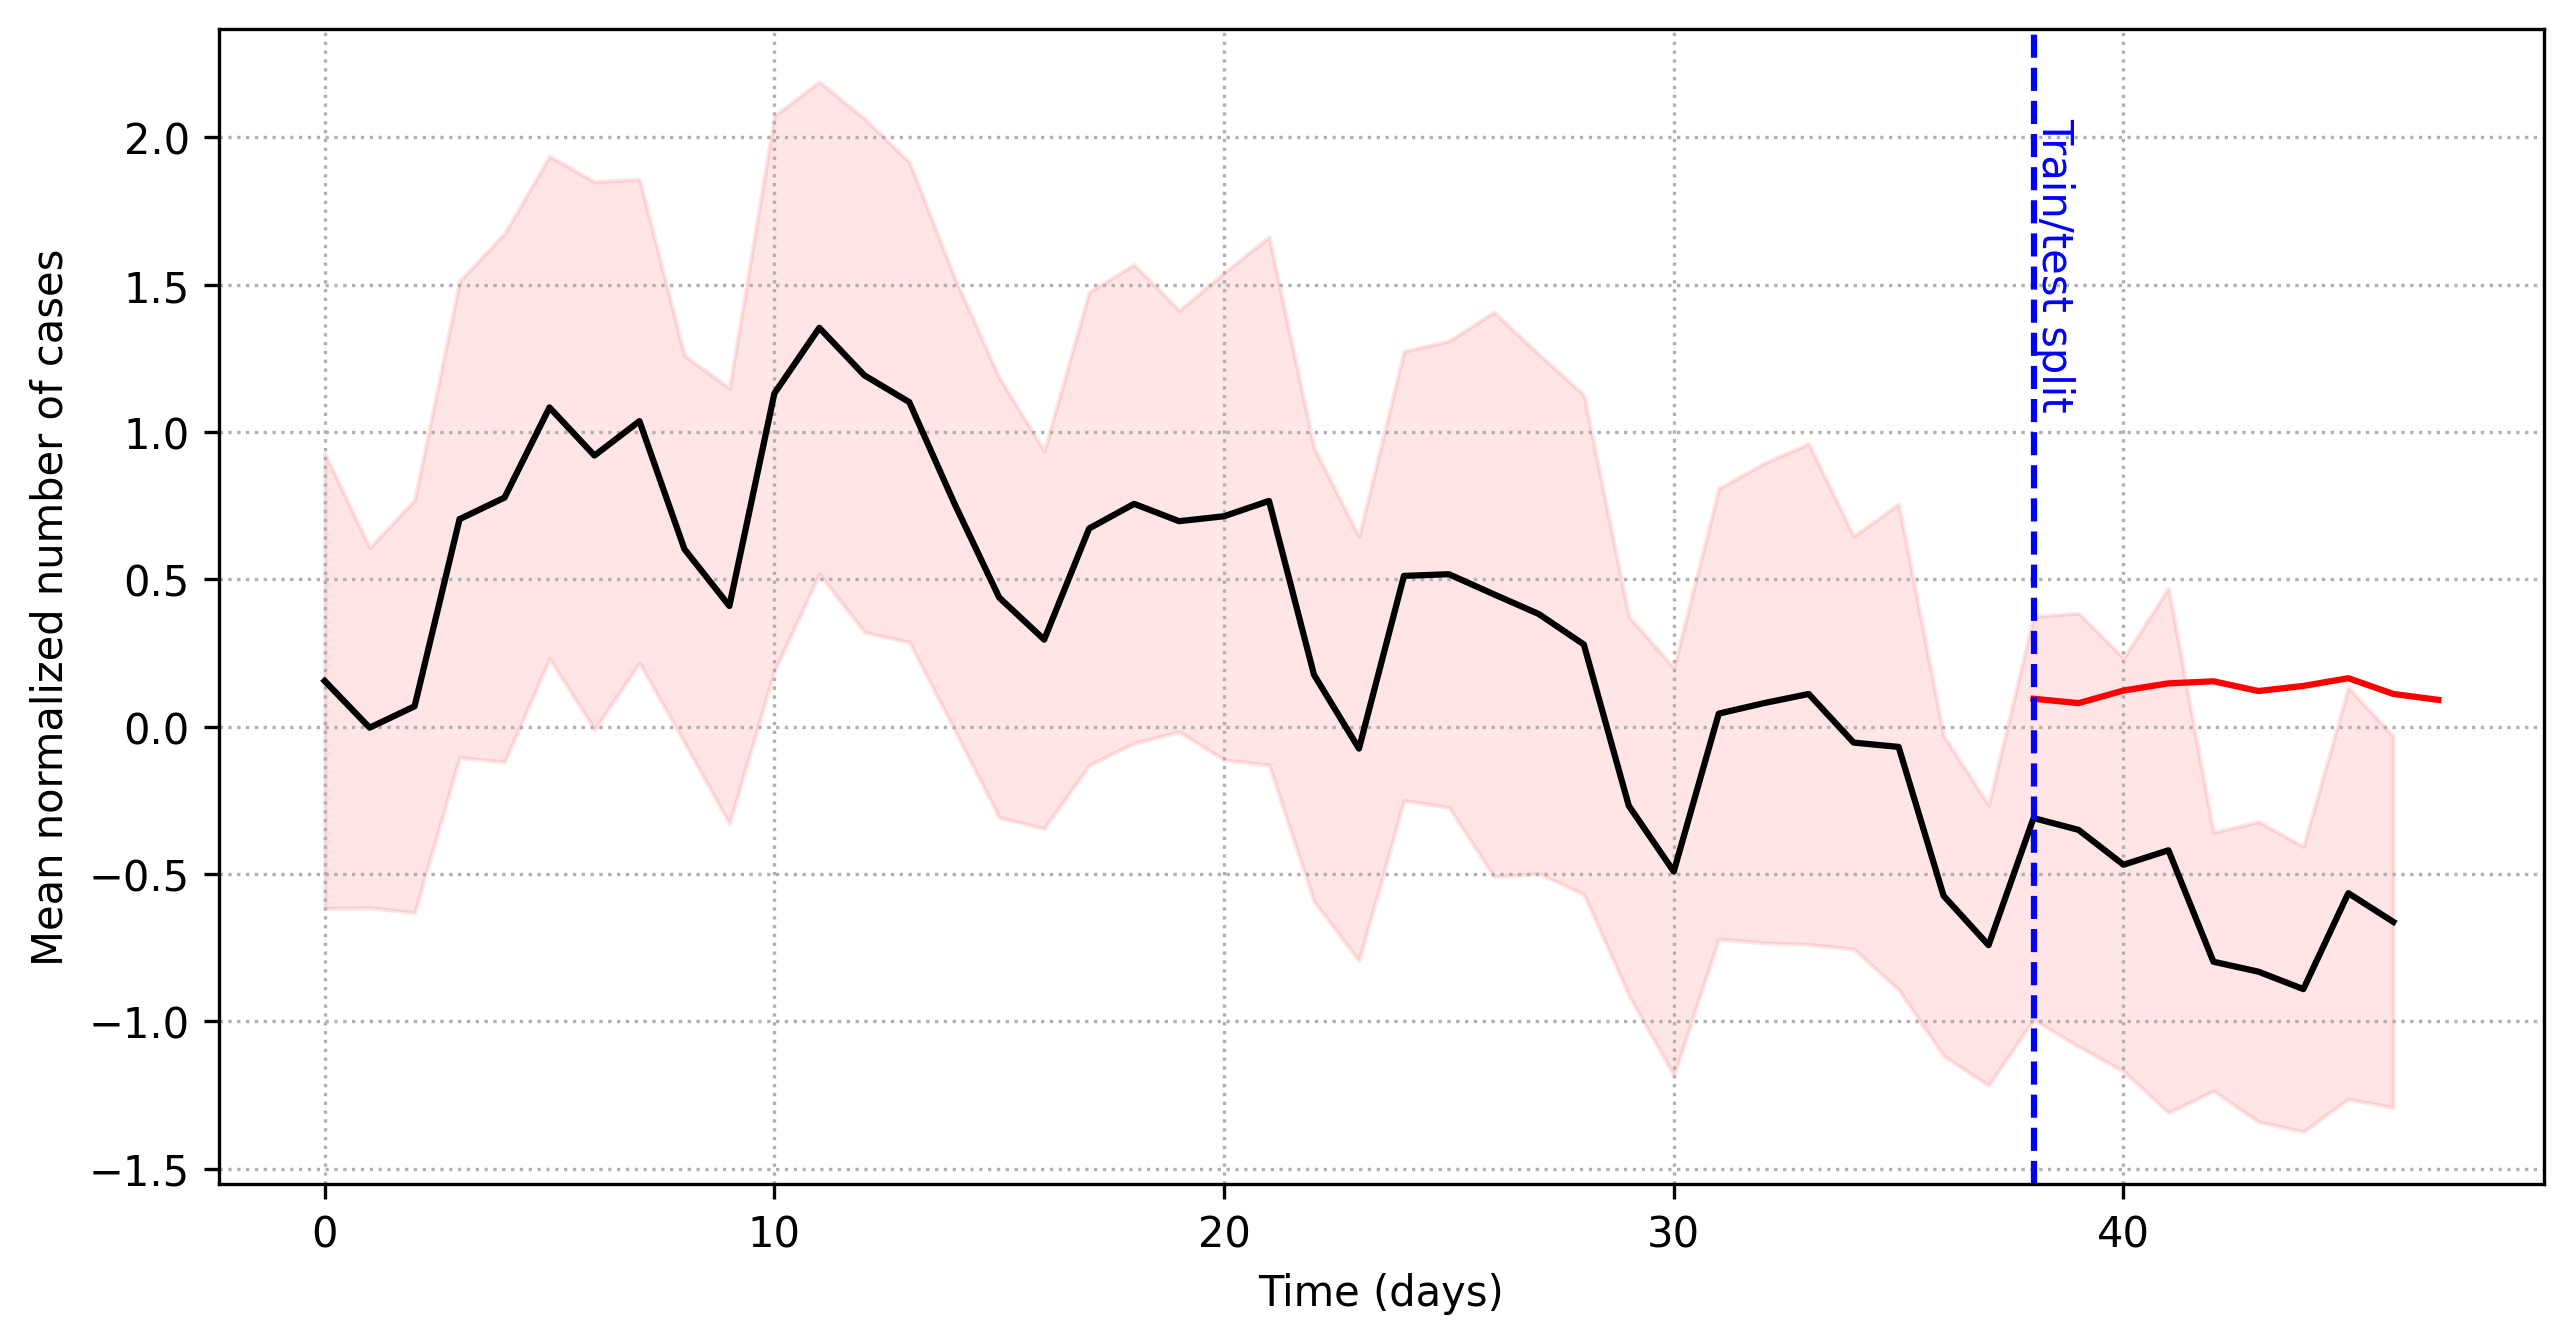

In [ ]:
# Plot do desempenho do modelo, onde as previsões do modelo para os snapshots de teste são calculadas e armazenadas na lista y_preds, 
# e em seguida, essas previsões são plotadas junto com a média real dos casos (df['mean']), permitindo uma comparação visual entre os valores reais e as previsões do modelo ao longo do tempo.
y_preds = [model(snapshot.x, snapshot.edge_index, snapshot.edge_attr).squeeze().detach().numpy().mean() for snapshot in test_dataset]

plt.figure(figsize=(10,5), dpi=300)
plt.plot(df['mean'], 'k-')
plt.plot(range(38,48), y_preds, 'r-', label='Prediction')
plt.grid(linestyle=':')
plt.fill_between(df.index, df['mean']-df['std'], df['mean']+df['std'], color='r', alpha=0.1)
plt.axvline(x=38, color='b', linestyle='--', label='Train/test split')
plt.text(38, 1.1, 'Train/test split', rotation=-90, color='b')
plt.xlabel('Time (days)')
plt.ylabel('Mean normalized number of cases')